<a href="https://colab.research.google.com/github/DecoAnalytics/AML-Final-Murillo-Miguel/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                   **PRESENCIA DE ENFERMEDAD CARDIACA**


## 1. Resumen Ejecutivo

El proyecto aborda el problema de negocio de identificar oportunamente la presencia de enfermedad cardiaca a partir de variables clínicas y demográficas de los pacientes, con el fin de apoyar decisiones médicas más rápidas y mejorar la priorización de casos con mayor riesgo. Este tipo de solución puede contribuir a optimizar la atención, reducir demoras diagnósticas y fortalecer estrategias preventivas en entornos de salud.

La metodología utilizada consistió en la construcción de un modelo predictivo de clasificación binaria sobre un conjunto de datos de 303 registros y 14 variables clínicas. Inicialmente se realizó un análisis exploratorio de datos para comprender la distribución de las variables y su relación con la presencia de enfermedad cardiaca. Posteriormente, se aplicó transformación de variables categóricas mediante variables dummy, estandarización de datos y partición del conjunto en entrenamiento y prueba. Como modelo principal, se implementó una red neuronal artificial (ANN) con dos capas ocultas y función de activación ReLU, utilizando Adam como optimizador y entropía cruzada binaria como función de pérdida. Además, se comparó su desempeño con un modelo Random Forest.

Entre los principales hallazgos, la red neuronal alcanzó una exactitud aproximada de 86.9%, superando al modelo Random Forest, que obtuvo cerca de 80.3%. Asimismo, el análisis exploratorio mostró que variables como el tipo de dolor de pecho, la frecuencia cardiaca máxima, la presencia de angina inducida por ejercicio y algunos indicadores electrocardiográficos presentan relación relevante con el diagnóstico.

El impacto esperado en el negocio es significativo, ya que este modelo puede servir como herramienta de apoyo a la decisión clínica, ayudando a identificar pacientes con mayor probabilidad de enfermedad cardiaca, mejorar la asignación de recursos, fortalecer la detección temprana y contribuir a una atención más eficiente y oportuna.

## 2. Configuración del Entorno

In [ ]:
import numpy as np
import pandas as pd

import os
#print(os.listdir("../input"))


### 2.2 Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.svm import SVC
%matplotlib inline

### 2.4 Conexión con Github (para cargar datos)

In [ ]:
url="https://raw.githubusercontent.com/DecoAnalytics/AML-Final-Murillo-Miguel/refs/heads/main/data/heart.csv"
df=pd.read_csv(url)
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

El presente proyecto se ubica en el sector salud, específicamente en el ámbito de la atención clínica y apoyo al diagnóstico médico de enfermedades cardiovasculares. Las enfermedades cardiacas representan una de las principales causas de morbilidad y mortalidad a nivel mundial, por lo que su detección temprana constituye una prioridad para los servicios de salud, tanto públicos como privados.

El caso de estudio corresponde al desarrollo de un modelo predictivo de clasificación basado en variables clínicas y demográficas de pacientes, tales como edad, sexo, tipo de dolor de pecho, presión arterial en reposo, colesterol, frecuencia cardiaca máxima, presencia de angina inducida por ejercicio, entre otras. El objetivo es estimar la probabilidad de que un paciente presente enfermedad cardiaca.

En la situación actual, el diagnóstico de estas enfermedades depende en gran medida de la evaluación médica, pruebas complementarias y análisis clínico especializado. Sin embargo, en escenarios con alta demanda asistencial, limitaciones de tiempo o recursos restringidos, puede resultar valioso contar con herramientas analíticas que ayuden a identificar pacientes de mayor riesgo de forma rápida y objetiva. En este contexto, el uso de machine learning ofrece una oportunidad para fortalecer la toma de decisiones, priorizar casos y mejorar la eficiencia del proceso de atención.

### 3.2 Problema a Resolver

El problema específico consiste en predecir si un paciente presenta o no enfermedad cardiaca a partir de un conjunto de variables clínicas disponibles al momento de la evaluación.

Resolver este problema es importante porque una detección tardía o una valoración inicial insuficiente puede retrasar la atención especializada, aumentar el riesgo de complicaciones y afectar negativamente los resultados clínicos del paciente. Además, en entornos asistenciales con alta carga operativa, la identificación temprana de pacientes con mayor probabilidad de enfermedad cardiaca puede mejorar la priorización médica y el uso de recursos diagnósticos.

Actualmente, la ausencia de una herramienta predictiva complementaria puede generar dependencia exclusiva del juicio clínico inicial, lo que podría incrementar la variabilidad en la evaluación, especialmente en contextos de alta demanda. El impacto actual del problema se traduce en posibles retrasos en la detección, mayores costos asistenciales, uso menos eficiente de pruebas diagnósticas y menor capacidad para implementar estrategias preventivas y de intervención oportuna.

Por ello, se plantea el desarrollo de un modelo de machine learning que contribuya a apoyar la decisión clínica, estimando de manera automatizada la presencia de enfermedad cardiaca con base en patrones identificados en los datos.

### 3.3 Objetivos del Proyecto

**Objetivo General:**
Desarrollar y evaluar, en un periodo de ejecución del proyecto, un modelo de Machine learning capaz de predecir la presencia de enfermedad cardiaca a partir de variables clínicas y demográficas, con un nivel de desempeño adecuado para apoyar la toma de decisiones en contextos de atención en salud.

**Objetivos Específicos:**
Analizar y preparar la base de datos de pacientes con variables clínicas y demográficas, realizando exploración, transformación de variables categóricas y estandarización de datos antes del entrenamiento del modelo.

Construir y entrenar un modelo de red neuronal artificial para clasificar la presencia o ausencia de enfermedad cardiaca, y medir su desempeño mediante métricas como accuracy y matriz de confusión.

Comparar el desempeño del modelo de red neuronal con un modelo alternativo de Random Forest para determinar cuál ofrece mejores resultados predictivos y mayor utilidad como herramienta de apoyo al diagnóstico.

---

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [x] Clasificación binaria
- [ ] Clasificación multiclase
- [ ] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**
Este proyecto corresponde a un problema de clasificación binaria porque la variable objetivo solo tiene dos posibles resultados: presencia de enfermedad cardiaca o ausencia de enfermedad cardiaca. El modelo no busca estimar un valor numérico continuo, ni agrupar observaciones sin etiquetas, sino asignar cada paciente a una de dos clases definidas previamente.

La elección de este tipo de problema es adecuada porque el objetivo del negocio es apoyar una decisión concreta: identificar si un paciente presenta riesgo compatible con enfermedad cardiaca. En el notebook, esta formulación se implementa mediante una variable objetivo binaria (target) y el uso de algoritmos supervisados como una red neuronal artificial y un Random Forest, ambos orientados a clasificación. Además, la evaluación del desempeño se realiza con métricas propias de este tipo de problema, como la exactitud, la matriz de confusión y la curva ROC, lo que confirma que la formulación como clasificación binaria es la más apropiada.

## 4. Exploración de Datos

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 4.2 Descripción del Dataset

https://archive.ics.uci.edu/dataset/45/heart+disease

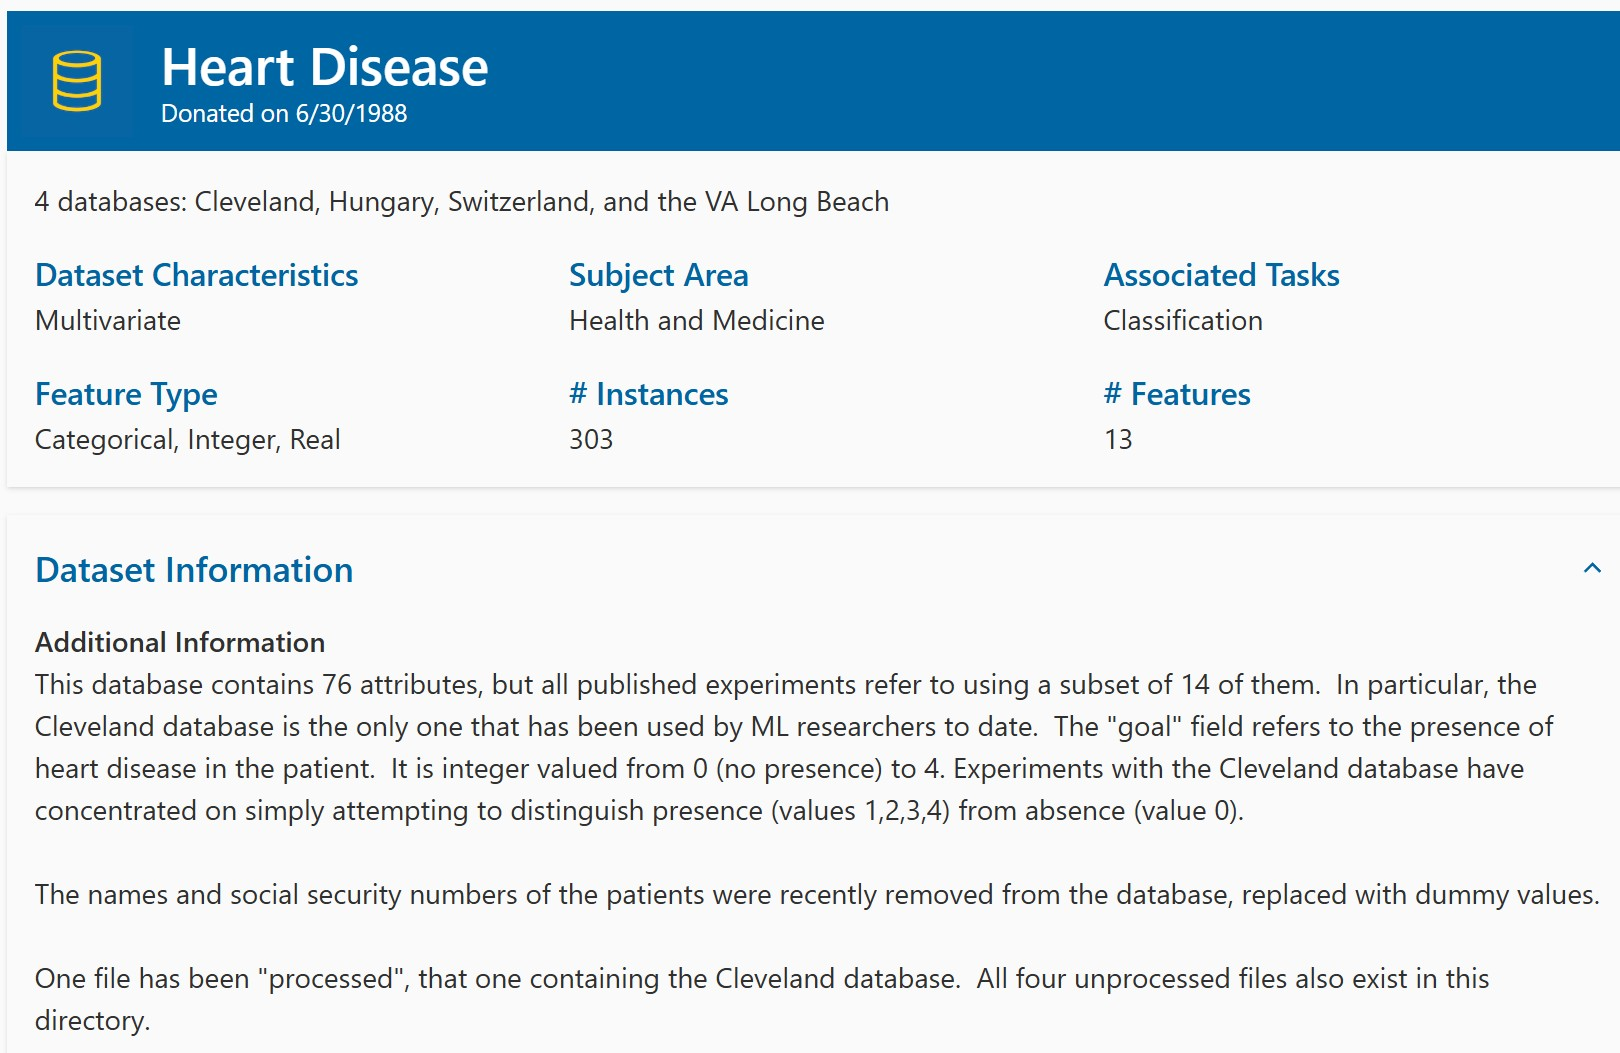

Es un conjunto de datos claro y fácil de entender. Sin embargo, el significado de algunos encabezados de columna no es evidente. A continuación, se explica su significado:

1.age: La edad de la persona en años

2.sex: El sexo de la persona (1 = male, 0 = female)

3.cp: El dolor en el pecho experimentado (Value 1: typical angina, Value 2: atypical angina, Value 3: non-anginal pain, Value 4: asymptomatic)

4.trestbps: La presión arterial en reposo de la persona (mm Hg on admission to the hospital)

5.chol: La medición del colesterol de la persona en mg/dl

6.fbs: El nivel de azúcar en sangre en ayunas de la persona (> 120 mg/dl, 1 = true; 0 = false)

7.restecg: Medición electrocardiográfica en reposo (0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria)

8.thalach: La frecuencia cardíaca máxima alcanzada por la persona

9.exang: Angina inducida por el ejercicio (1 = yes; 0 = no)

10.oldpeak: Depresión del segmento ST inducida por el ejercicio en relación con el reposo (el ST se refiere a las posiciones en el gráfico del ECG. Ver más aquí)

11.slope: la pendiente del segmento ST del ejercicio máximo (Value 1: upsloping, Value 2: flat, Value 3: downsloping)

12.ca: El número de major vessels (0-3)

13.thal: Un trastorno sanguíneo llamado talasemia (3 = normal; 6 = fixed defect; 7 = reversable defect)

14.target: Cardiopatía (0 = no, 1 = yes)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### 5. Codificación de Variables Categóricas

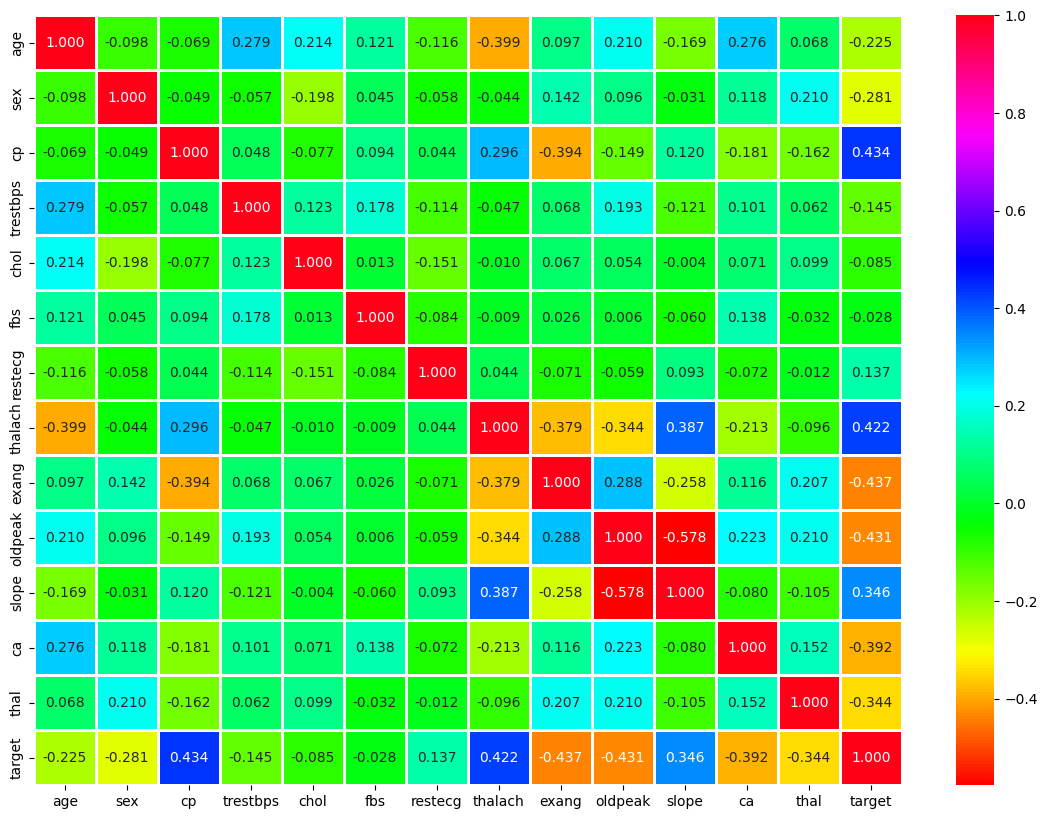

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),annot=True,cmap='hsv',fmt='.3f',linewidths=2)
plt.show()

In [ ]:
df.groupby('cp',as_index=False)['target'].mean()

,cp,target
0,0,0.272727
1,1,0.820000
2,2,0.793103
3,3,0.695652


In [ ]:
df.groupby('slope',as_index=False)['target'].mean()

,slope,target
0,0,0.428571
1,1,0.350000
2,2,0.753521


In [ ]:
df.groupby('thal',as_index=False)['target'].mean()

,thal,target
0,0,0.500000
1,1,0.333333
2,2,0.783133
3,3,0.239316


In [ ]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


/tmp/ipykernel_451/925223036.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['target'],rug=True)


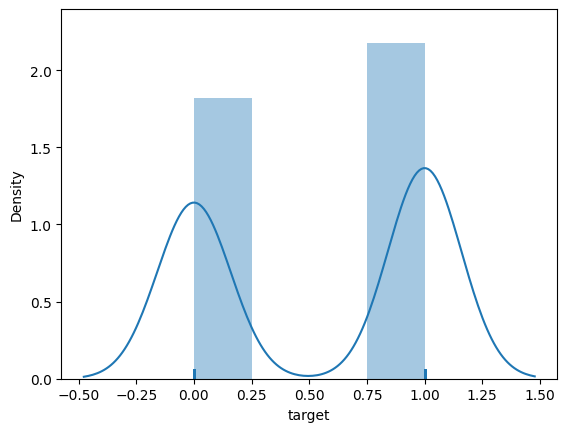

In [ ]:
sns.distplot(df['target'],rug=True)
plt.show()

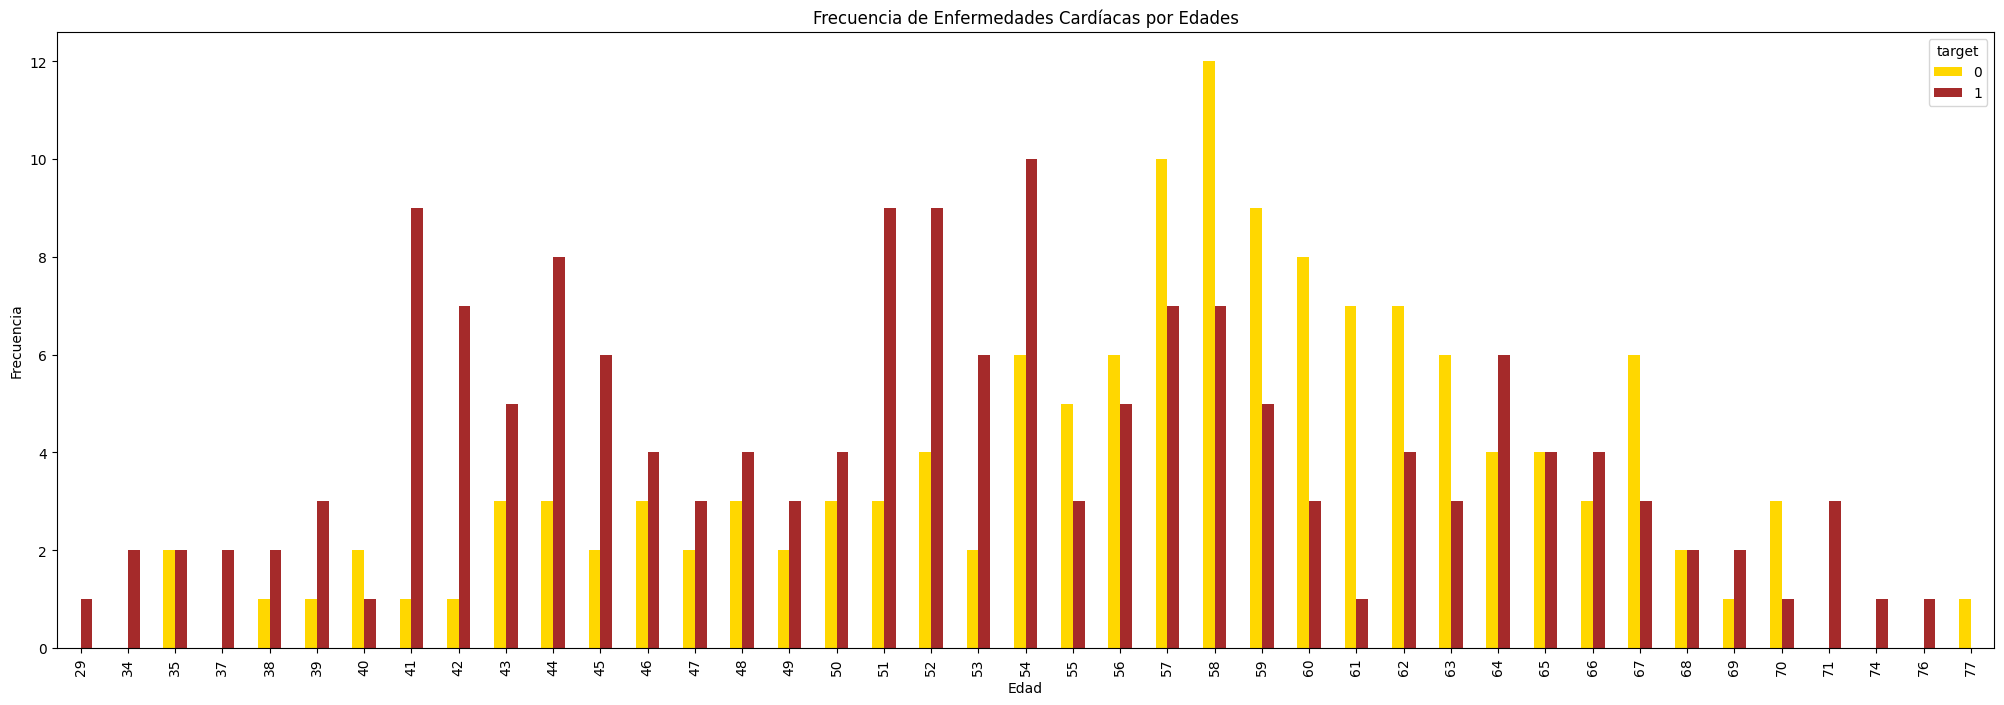

In [ ]:
pd.crosstab(df.age,df.target).plot(kind="bar",figsize=(25,8),color=['gold','brown' ])
plt.title('Frecuencia de Cardiopatía por Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

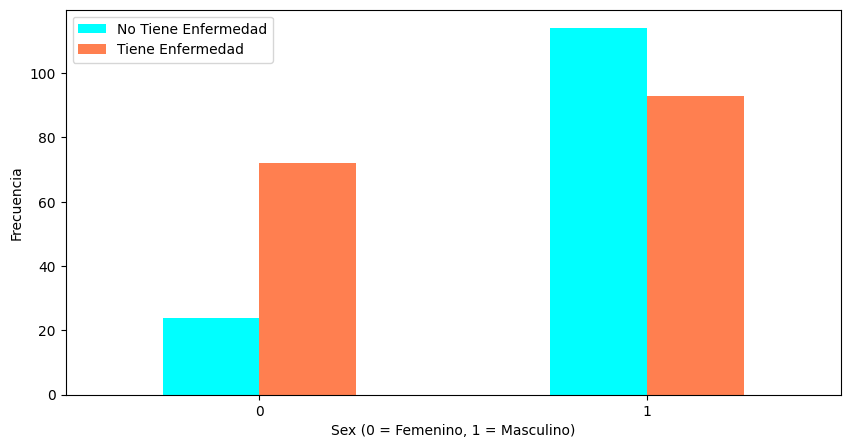

In [ ]:
pd.crosstab(df.sex,df.target).plot(kind="bar",figsize=(10,5),color=['cyan','coral' ])
plt.xlabel('Sex (0 = Femenino, 1 = Masculino)')
plt.xticks(rotation=0)
plt.legend(["No Tiene Enfermedad", "Tiene Enfermedad"])
plt.ylabel('Frecuencia')
plt.show()

/tmp/ipykernel_451/2646946682.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['target'], y=df['trestbps'], palette = 'rainbow')


Text(0.5, 1.0, 'Relación de los tresbps con el objetivo')

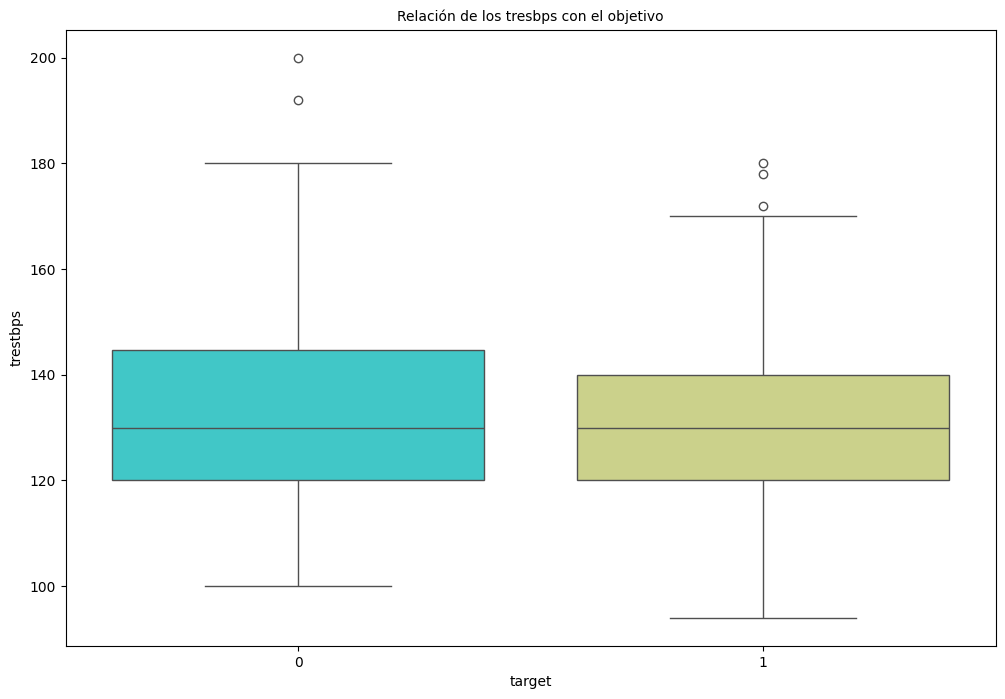

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(x=df['target'], y=df['trestbps'], palette = 'rainbow')
plt.title('Relación de los tresbps con el objetivo', fontsize = 10)

La trama sugiere claramente que los pacientes que tienen más probabilidades de no sufrir la enfermedad tienen una presión arterial ligeramente mayor que los pacientes que tienen enfermedades cardíacas.

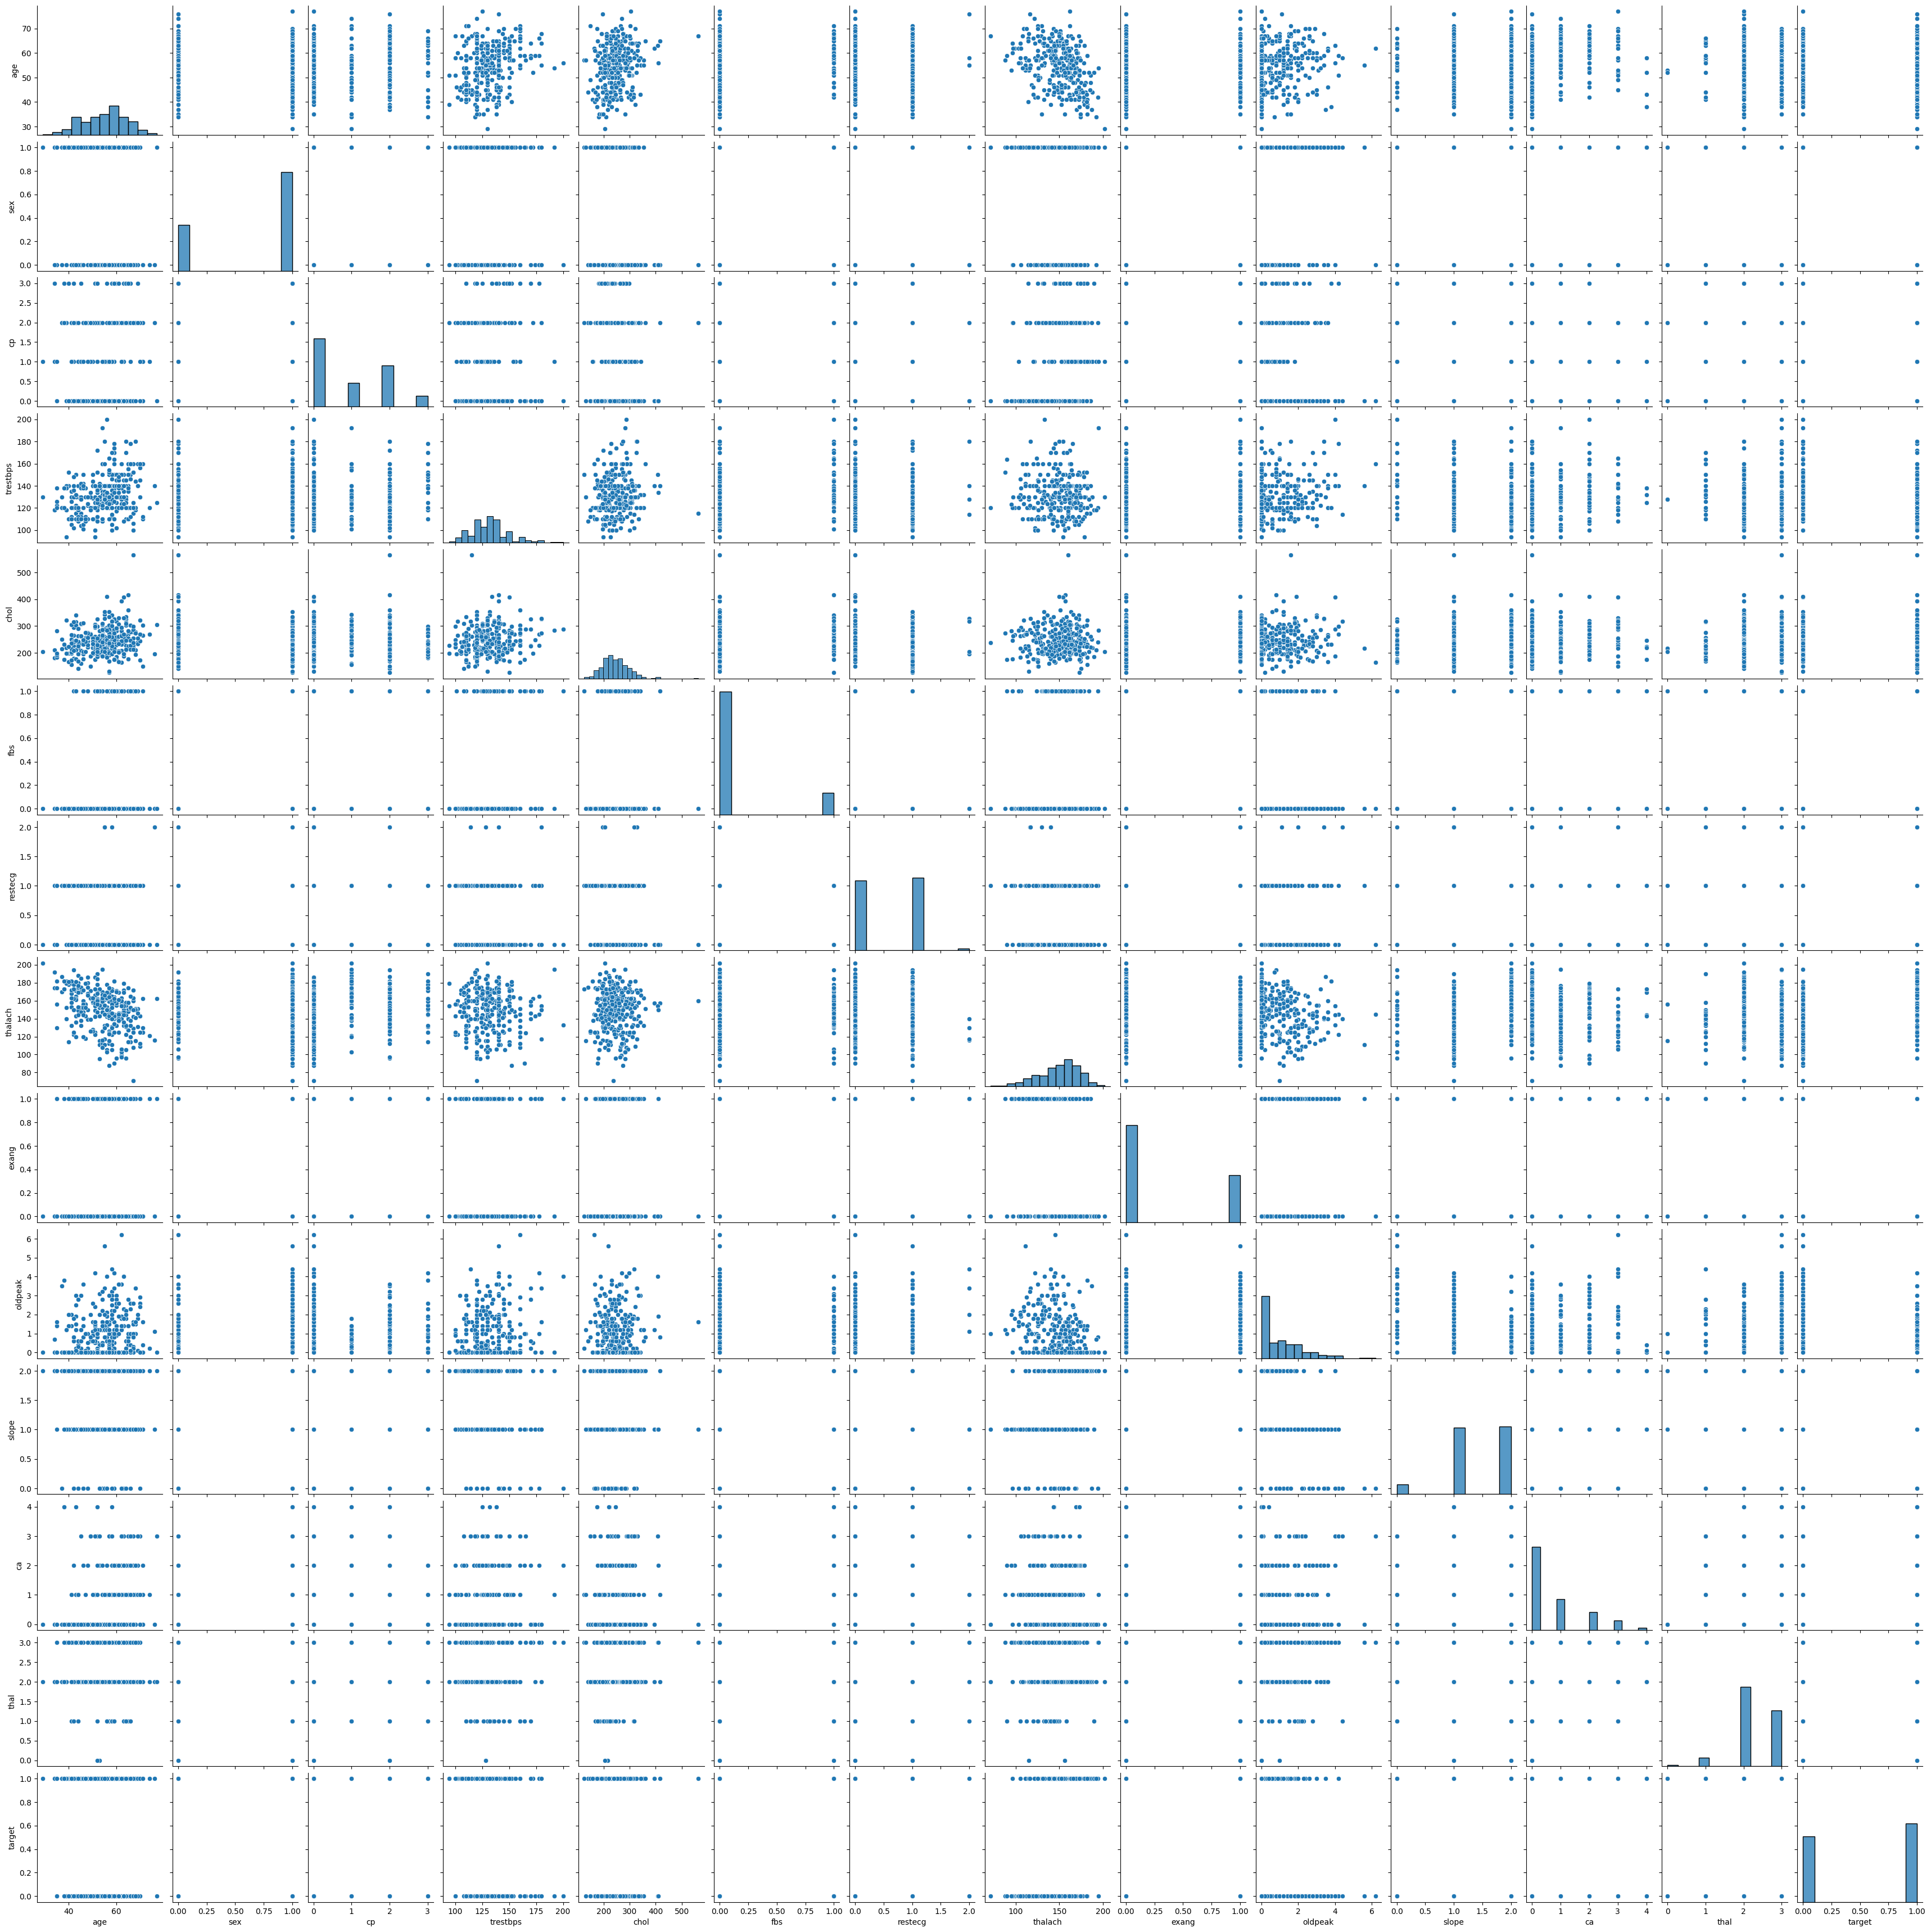

In [ ]:
sns.pairplot(data=df)

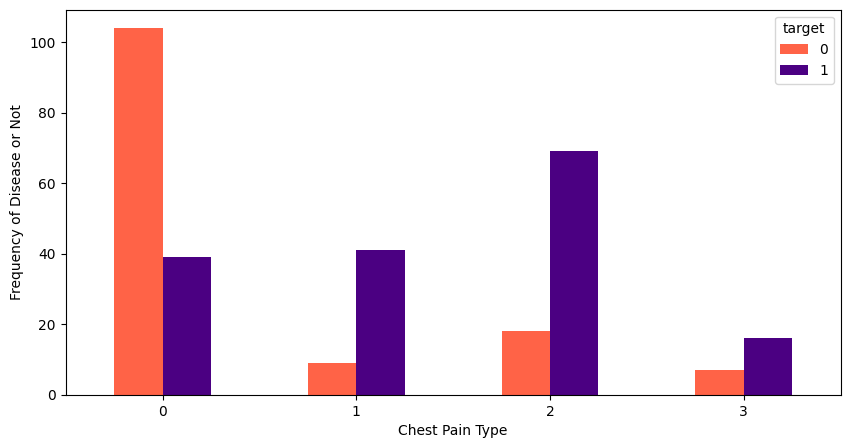

In [ ]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,5),color=['tomato','indigo' ])
plt.xlabel('Chest Pain Type')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()


## Efecto de los parámetros sobre la enfermedad cardíaca en función de la edad

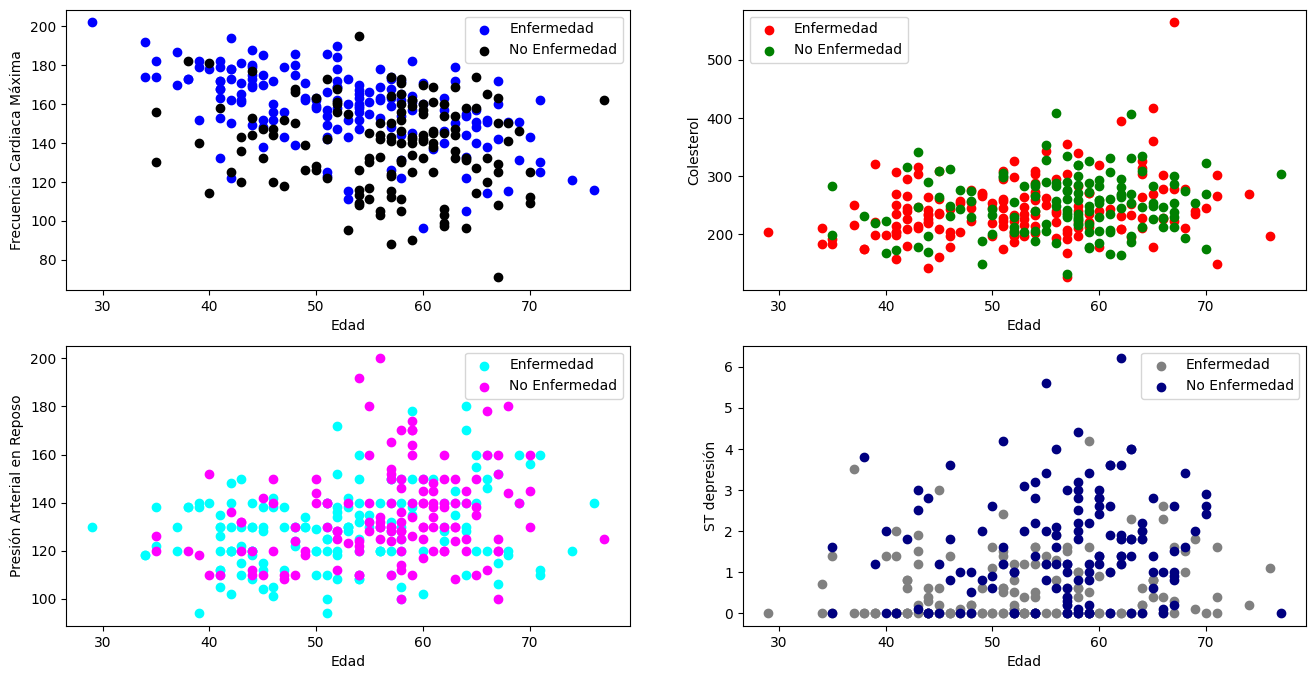

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
plt.scatter(x=df.age[df.target==1],y=df.thalach[df.target==1],c='blue')
plt.scatter(x=df.age[df.target==0],y=df.thalach[df.target==0],c='black')
plt.xlabel('Edad')
plt.ylabel('Frecuencia Cardiaca Máxima')
plt.legend(['Enfermedad','No Enfermedad'])

plt.subplot(2,2,2)
plt.scatter(x=df.age[df.target==1],y=df.chol[df.target==1],c='red')
plt.scatter(x=df.age[df.target==0],y=df.chol[df.target==0],c='green')
plt.xlabel('Edad')
plt.ylabel('Colesterol')
plt.legend(['Enfermedad','No Enfermedad'])

plt.subplot(2,2,3)
plt.scatter(x=df.age[df.target==1],y=df.trestbps[df.target==1],c='cyan')
plt.scatter(x=df.age[df.target==0],y=df.trestbps[df.target==0],c='fuchsia')
plt.xlabel('Edad')
plt.ylabel('Presión Arterial en Reposo')
plt.legend(['Enfermedad','No Enfermedad'])

plt.subplot(2,2,4)
plt.scatter(x=df.age[df.target==1],y=df.oldpeak[df.target==1],c='grey')
plt.scatter(x=df.age[df.target==0],y=df.oldpeak[df.target==0],c='navy')
plt.xlabel('Edad')
plt.ylabel('ST depresión')
plt.legend(['Enfermedad','No Enfermedad'])
plt.show()

## Creación de variables ficticias

In [ ]:
chest_pain=pd.get_dummies(df['cp'],prefix='cp',drop_first=True)
df=pd.concat([df,chest_pain],axis=1)
df.drop(['cp'],axis=1,inplace=True)
sp=pd.get_dummies(df['slope'],prefix='slope')
th=pd.get_dummies(df['thal'],prefix='thal')
rest_ecg=pd.get_dummies(df['restecg'],prefix='restecg')
frames=[df,sp,th,rest_ecg]
df=pd.concat(frames,axis=1)
df.drop(['slope','thal','restecg'],axis=1,inplace=True)

In [ ]:
df.head(5)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3,restecg_0,restecg_1,restecg_2
0,63,1,145,233,1,150,0,2.3,0,1,...,True,False,False,False,True,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,1,...,True,False,False,False,False,True,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,1,...,False,False,True,False,False,True,False,True,False,False
3,56,1,120,236,0,178,0,0.8,0,1,...,False,False,True,False,False,True,False,False,True,False
4,57,0,120,354,0,163,1,0.6,0,1,...,False,False,True,False,False,True,False,False,True,False


In [ ]:
X = df.drop(['target'], axis = 1)
y = df.target.values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Importación de las bibliotecas y paquetes de Keras

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
import keras
from keras.models import Sequential
from keras.layers import Dense
import warnings

## Keras neural network

Keras es una potente biblioteca de Python fácil de usar para desarrollar y evaluar modelos de aprendizaje profundo. Integra las eficientes bibliotecas de cálculo numérico Theano y TensorFlow y permite definir y entrenar modelos de redes neuronales en pocas líneas de código.


## Inicializando la ANN

A continuación, construirás tu red. Hemos desarrollado la estructura y el pase hacia atrás. Implementarás el pase hacia adelante a través de la red. También configurarás los hiperparámetros: la tasa de aprendizaje, el número de unidades ocultas y el número de pases de entrenamiento.

La red tiene dos capas: una oculta y una de salida. La oculta utiliza la función sigmoidea para las activaciones. La capa de salida tiene un solo nodo y se utiliza para la regresión; la salida del nodo es la misma que la entrada. Es decir, la función de activación es $f(x)=x$. Una función que toma la señal de entrada y genera una señal de salida, pero tiene en cuenta el umbral, se denomina función de activación. Trabajamos en cada capa de nuestra red calculando las salidas de cada neurona. Todas las salidas de una capa se convierten en entradas para las neuronas de la siguiente capa. Este proceso se denomina propagación hacia adelante.

Usamos los pesos para propagar señales hacia adelante desde las capas de entrada hasta las de salida en una red neuronal. También los usamos para propagar errores hacia atrás desde la salida hacia la red y actualizar nuestros pesos. Esto se denomina retropropagación.

In [ ]:
classifier = Sequential()

# Adding the input layer and the first hidden layer
classifier.add(Dense(units = 11, kernel_initializer = 'uniform', activation = 'relu', input_dim = 22))

# Adding the second hidden layer
classifier.add(Dense(units = 11, kernel_initializer = 'uniform', activation = 'relu'))

# Adding the output layer
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

# Compiling the ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Neurona

Las neuronas son la unidad básica de una red neuronal. Cuando la neurona artificial se activa, calcula su estado sumando todas las entradas entrantes multiplicadas por su peso de conexión correspondiente. Sin embargo, las neuronas siempre tienen una entrada adicional, el sesgo, que siempre es 1, y tiene su propio peso de conexión.

## Descenso de gradiente

El descenso de gradiente es un algoritmo de optimización iterativo de primer orden para hallar el mínimo de una función. Para hallar un mínimo local de una función mediante el descenso de gradiente, se realizan pasos proporcionales al negativo del gradiente (o gradiente aproximado) de la función en el punto actual.

## Backpropagation

Backpropagation (backward propagation) es una herramienta matemática importante para mejorar la precisión de las predicciones en la minería de datos y el aprendizaje automático.Esencialmente, backpropagation es un algoritmo utilizado para calcular derivadas rápidamente.
Las redes neuronales artificiales usa backpropagation como algoritmo de aprendizaje para calcular un descenso de gradiente con respecto a los pesos. Las salidas deseadas se comparan con las salidas obtenidas del sistema, y ​​luego los sistemas se optimizan ajustando los pesos de conexión para minimizar la diferencia entre ambos. El algoritmo recibe su nombre porque los pesos se actualizan en sentido inverso, desde la salida hacia la entrada.

# Ajuste del modelo

### Elija el número de épocas
Este es el número de veces que el conjunto de datos pasará por la red, actualizando los pesos cada vez. A medida que aumenta el número de épocas, la red mejora su capacidad para predecir los objetivos del conjunto de entrenamiento. Deberá elegir suficientes épocas para entrenar bien la red, pero no demasiadas, ya que se producirá un sobreajuste.

In [ ]:
classifier.fit(X_train, y_train, batch_size = 10, epochs = 100)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5472 - loss: 0.6930
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8097 - loss: 0.6904 
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7651 - loss: 0.6771
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8067 - loss: 0.6403
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7992 - loss: 0.5882 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8397 - loss: 0.5204
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8510 - loss: 0.4504
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.3849 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8352 - loss: 0.3872
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8625 - loss: 0.3571 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8577 - loss: 0.3733 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accu

In [ ]:
# Predicción de los resultados del conjunto de pruebas
y_pred = classifier.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


accuracy of the model:  0.8688524590163934


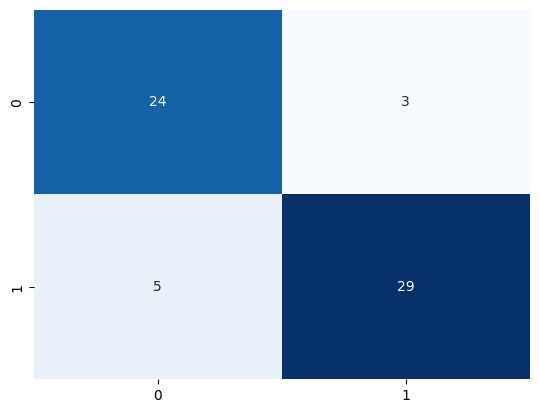

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred.round())
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d",cbar=False)
#accuracy score
from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test, y_pred.round())
print('accuracy of the model: ',ac)

RandomForest_accuracy: 0.8032786885245902


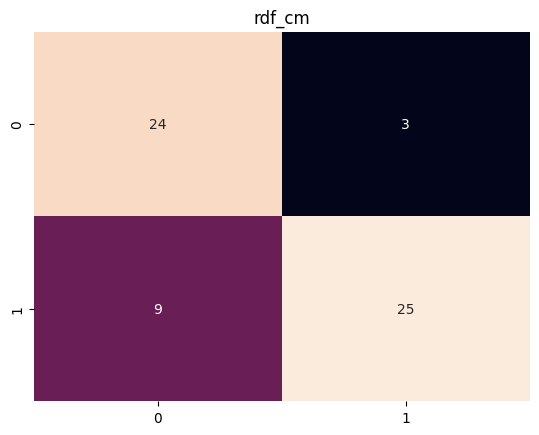

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rdf_c=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)
rdf_c.fit(X_train,y_train)
rdf_pred=rdf_c.predict(X_test)
rdf_cm=confusion_matrix(y_test,rdf_pred)
rdf_ac=accuracy_score(rdf_pred,y_test)
plt.title("rdf_cm")
sns.heatmap(rdf_cm,annot=True,fmt="d",cbar=False)
print('RandomForest_accuracy:',rdf_ac)

<Figure size 640x480 with 0 Axes>

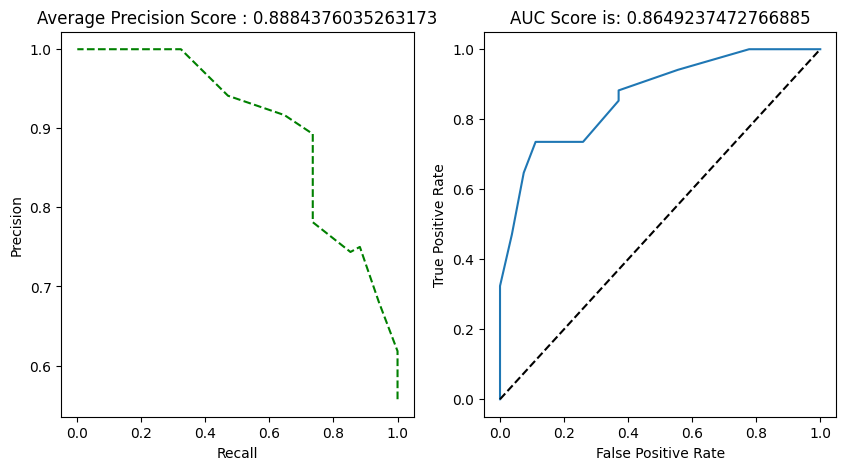

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
%matplotlib inline
def plotting(true,pred):
    fig,ax=plt.subplots(1,2,figsize=(10,5))
    precision,recall,threshold = precision_recall_curve(true,pred[:,1])
    ax[0].plot(recall,precision,'g--')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title("Average Precision Score : {}".format(average_precision_score(true,pred[:,1])))
    fpr,tpr,threshold = roc_curve(true,pred[:,1])
    ax[1].plot(fpr,tpr)
    ax[1].set_title("AUC Score is: {}".format(auc(fpr,tpr)))
    ax[1].plot([0,1],[0,1],'k--')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
plotting(y_test,rdf_c.predict_proba(X_test))
plt.figure()


La **curva ROC**. En una curva ROC, la tasa de verdaderos positivos (sensibilidad) se representa en función de la tasa de falsos positivos (especificidad 100) para diferentes puntos de corte. Cada punto de la curva ROC representa un par de sensibilidad/especificidad correspondiente a un umbral de decisión particular.

Dado que el área bajo la curva ROC mide la utilidad de una prueba en general, donde un área mayor implica una prueba más útil, las áreas bajo la curva ROC se utilizan para comparar la utilidad de las pruebas. El término ROC significa Característica Operativa del Receptor (ROC).

Text(0.5, 1.0, 'Model Acuracy')

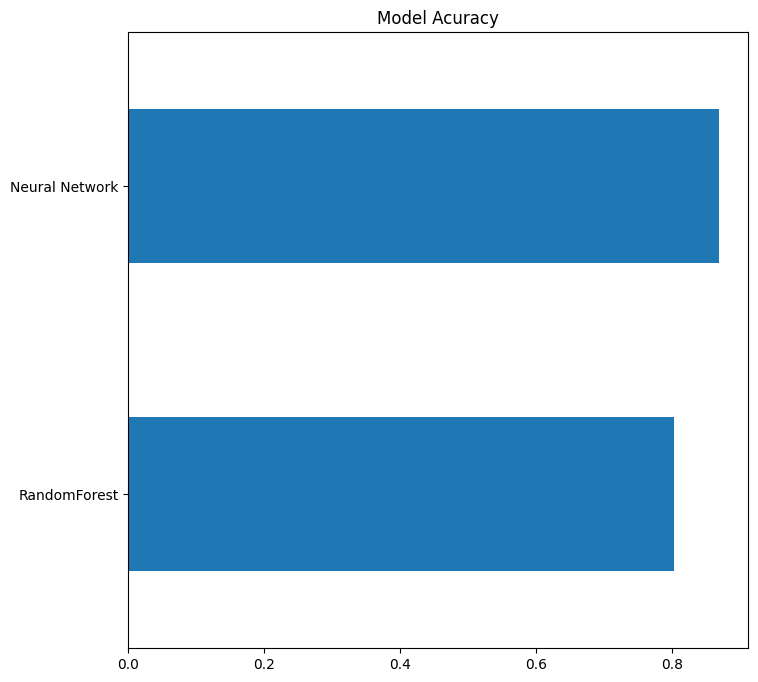

In [ ]:
model_accuracy = pd.Series(data=[rdf_ac,ac],
        index=['RandomForest','Neural Network'])
fig= plt.figure(figsize=(8,8))
model_accuracy.sort_values().plot.barh()
plt.title('Model Acuracy')

##10. Conclusiones y Recomendaciones de Negocio

#10.1 Resumen de Resultados
El proyecto permitió desarrollar y evaluar un modelo de machine learning orientado a la predicción de presencia de enfermedad cardiaca a partir de variables clínicas y demográficas de los pacientes. Para ello, se realizó un proceso de preparación de datos que incluyó exploración, transformación de variables categóricas, estandarización de variables numéricas y partición del dataset en conjuntos de entrenamiento y prueba.

Como modelo principal se implementó una red neuronal artificial (ANN) con dos capas ocultas, función de activación ReLU y salida sigmoide para clasificación binaria. Adicionalmente, se construyó un modelo comparativo de Random Forest con el fin de evaluar alternativas de desempeño.

Los resultados obtenidos muestran que la red neuronal alcanzó una exactitud de 86.89%, mientras que el modelo Random Forest obtuvo una exactitud de 80.33%. Esta diferencia evidencia que, para el conjunto de datos analizado, la red neuronal presentó una mejor capacidad de clasificación para identificar la presencia o ausencia de enfermedad cardiaca.

Asimismo, el análisis exploratorio previo permitió reconocer que ciertas variables clínicas presentan asociación relevante con el diagnóstico, lo cual respalda la utilidad del enfoque predictivo. En conjunto, los resultados demuestran que el modelo desarrollado tiene potencial para funcionar como una herramienta de apoyo a la decisión clínica, contribuyendo a una identificación más oportuna de pacientes con mayor probabilidad de enfermedad cardiaca.

#10.2 Conclusiones
En primer lugar, se concluye que sí es factible predecir la presencia de enfermedad cardiaca mediante técnicas de machine learning utilizando variables clínicas comúnmente disponibles en la evaluación del paciente. Esto confirma el valor de los modelos predictivos como soporte complementario en procesos de diagnóstico y priorización asistencial.

En segundo lugar, la red neuronal artificial mostró mejor desempeño que el modelo Random Forest, alcanzando una exactitud superior en el conjunto de prueba. Por tanto, dentro del alcance del proyecto, la red neuronal se posiciona como la alternativa más adecuada entre los modelos evaluados.

En tercer lugar, los resultados obtenidos sugieren que el uso de este tipo de soluciones puede generar valor en el negocio o en la operación sanitaria, al facilitar una detección temprana del riesgo, mejorar la priorización de pacientes y favorecer un uso más eficiente de recursos diagnósticos y asistenciales.

Finalmente, aunque el desempeño del modelo es favorable, también se concluye que esta solución debe entenderse como una herramienta de apoyo y no de reemplazo del criterio médico. Para una adopción real en un entorno clínico, será necesario complementar el desarrollo con validaciones adicionales, análisis de robustez y evaluación en datos de contextos reales.

#10.3 Recomendaciones de Negocio
Se recomienda considerar este modelo como un sistema de apoyo a la decisión clínica, integrándolo de manera progresiva en procesos de evaluación inicial o triaje, especialmente en contextos donde sea importante identificar rápidamente pacientes con mayor riesgo cardiovascular.

También se recomienda realizar una validación adicional con muestras más amplias y datos de entornos reales, ya que el dataset utilizado es relativamente pequeño. Esto permitiría verificar la estabilidad del modelo, mejorar su capacidad de generalización y aumentar la confianza para su uso operativo.

Desde una perspectiva de negocio, sería conveniente complementar la evaluación técnica con indicadores de impacto, tales como reducción en tiempos de atención, mejora en la priorización, disminución de errores de clasificación clínica inicial y optimización del uso de pruebas diagnósticas. De esta forma, el valor del modelo no solo se mediría por su accuracy, sino también por su contribución al desempeño organizacional.

Asimismo, se recomienda incorporar métricas adicionales como precisión, recall, F1-score, sensibilidad y especificidad, dado que en problemas de salud no basta con una buena exactitud general; es especialmente importante minimizar los falsos negativos, es decir, los casos de pacientes con enfermedad cardiaca que podrían no ser detectados por el modelo.

Por último, se sugiere establecer una hoja de ruta de madurez analítica que incluya el reentrenamiento periódico del modelo, monitoreo de desempeño, gobernanza de datos clínicos e integración con sistemas de información en salud, con el fin de convertir esta iniciativa en una solución sostenible y escalable.